In [56]:
# 1. INSTALLATION ET IMPORTS
!pip install yfinance pandas_ta keras-tcn

  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.

In [57]:
# Force la réinstallation de versions compatibles
!pip install --upgrade numpy==1.26.4
!pip install --upgrade scipy scikit-learn

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google

In [58]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, SimpleRNN, BatchNormalization, Bidirectional, Attention, GlobalAveragePooling1D, Add, MultiHeadAttention
from tensorflow.keras.utils import to_categorical
from tcn import TCN
from sklearn.preprocessing import RobustScaler
from sklearn.utils import class_weight
import matplotlib.cm as cm

[*********************100%***********************]  1 of 1 completed


Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'MACD', 'STOCH', 'BB_width', 'ADX', 'target']
Distribution des classes :
target
1.0    988
2.0    710
0.0    535
Name: count, dtype: int64
🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
🚀 Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


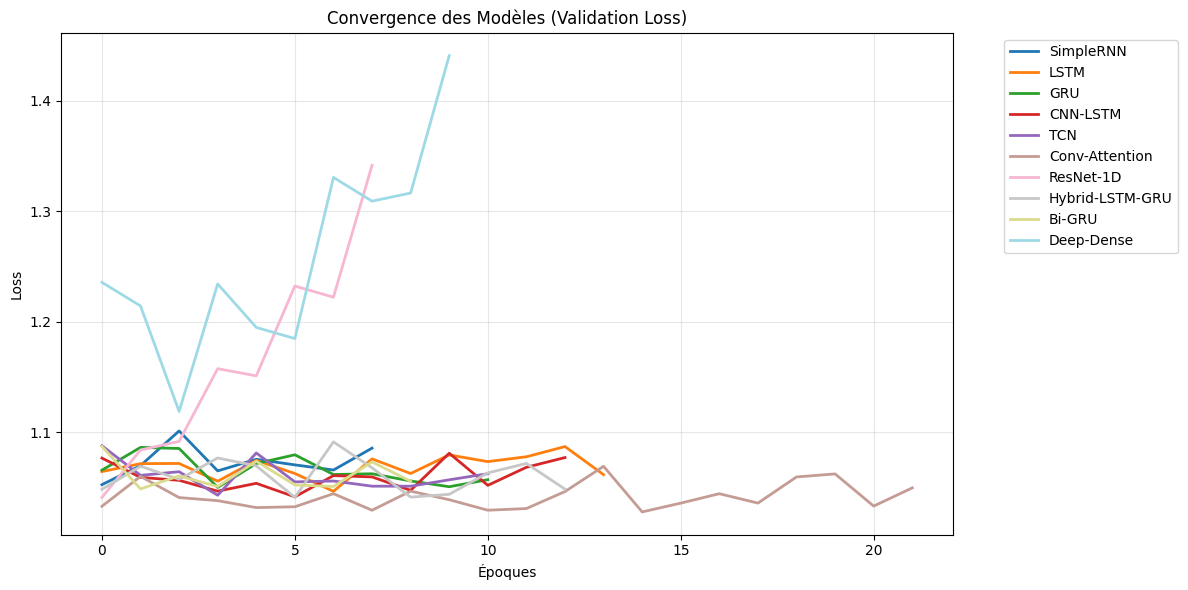


🏆 CLASSEMENT FINAL G1G2
1. TCN             : F1-Score = 0.3822
2. ResNet-1D       : F1-Score = 0.3661
3. LSTM            : F1-Score = 0.3610
4. GRU             : F1-Score = 0.3605
5. CNN-LSTM        : F1-Score = 0.3605
6. Conv-Attention  : F1-Score = 0.3605
7. Hybrid-LSTM-GRU : F1-Score = 0.3605
8. Bi-GRU          : F1-Score = 0.3605
9. SimpleRNN       : F1-Score = 0.3596
10. Deep-Dense      : F1-Score = 0.3454


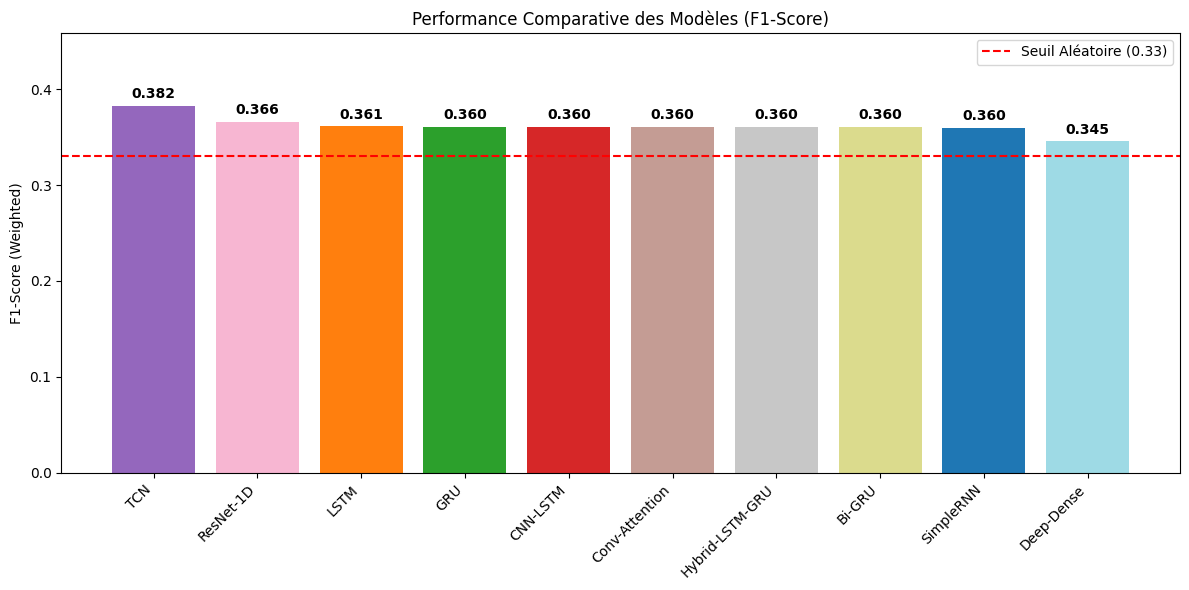

In [ ]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 60
HORIZON = 7
THRESHOLD = 0.035

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2020-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

macd = ta.macd(df['Close'])
df['MACD'] = macd.iloc[:, 0] / df['Close'] # Utilise la première colonne du MACD

stoch = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH'] = stoch.iloc[:, 0] / 100 # Utilise la ligne %K

bbands = ta.bbands(df['Close'], length=20, std=2)
# On calcule la largeur (Upper - Lower) en utilisant les positions plutôt que les noms
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']

adx = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX'] = adx.iloc[:, 0] / 100

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 'BB_width']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


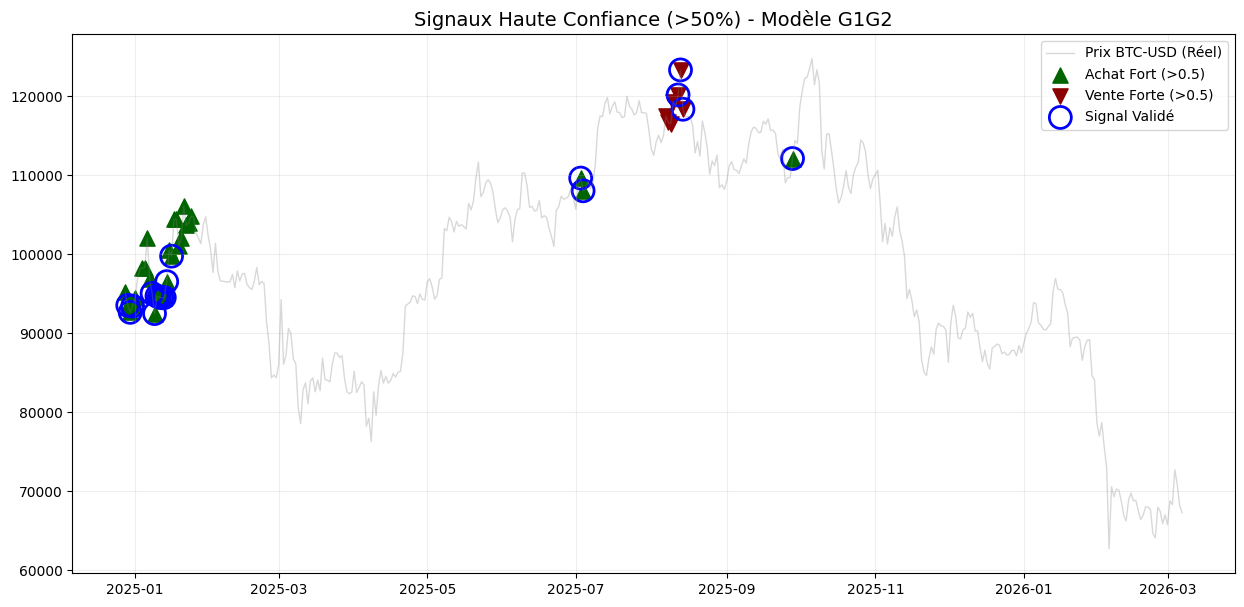

Nombre de signaux totaux : 310
Nombre de signaux forts (>0.5) : 36


In [60]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

## --> Même chose en enlevant des indicateurs et en allant chercher moins loin dans les datas

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    738
2.0    421
0.0    358
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
🚀 Training LSTM...


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


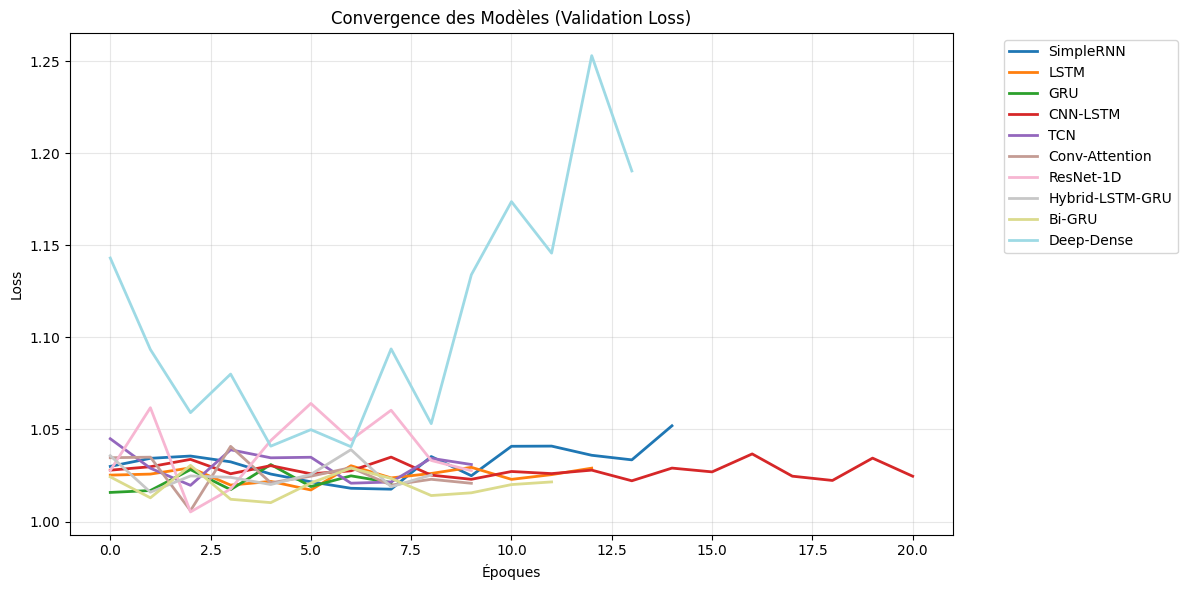


🏆 CLASSEMENT FINAL G1G2
1. Deep-Dense      : F1-Score = 0.4008
2. SimpleRNN       : F1-Score = 0.3919
3. LSTM            : F1-Score = 0.3919
4. GRU             : F1-Score = 0.3919
5. CNN-LSTM        : F1-Score = 0.3919
6. TCN             : F1-Score = 0.3919
7. Conv-Attention  : F1-Score = 0.3919
8. ResNet-1D       : F1-Score = 0.3919
9. Hybrid-LSTM-GRU : F1-Score = 0.3919
10. Bi-GRU          : F1-Score = 0.3919


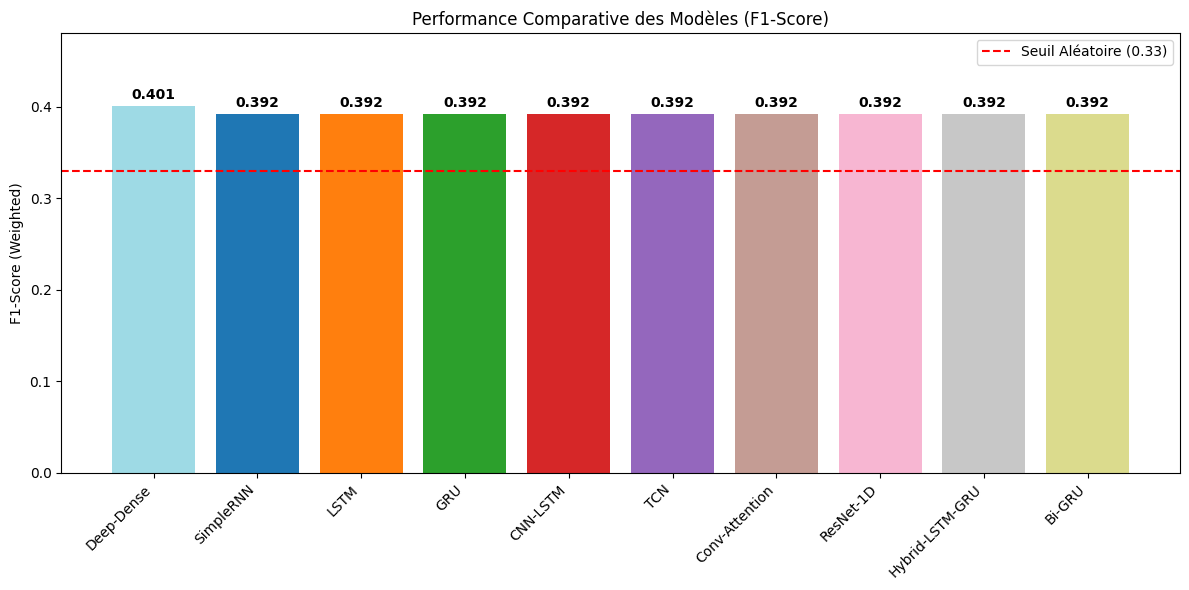

In [ ]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 60
HORIZON = 7
THRESHOLD = 0.035

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


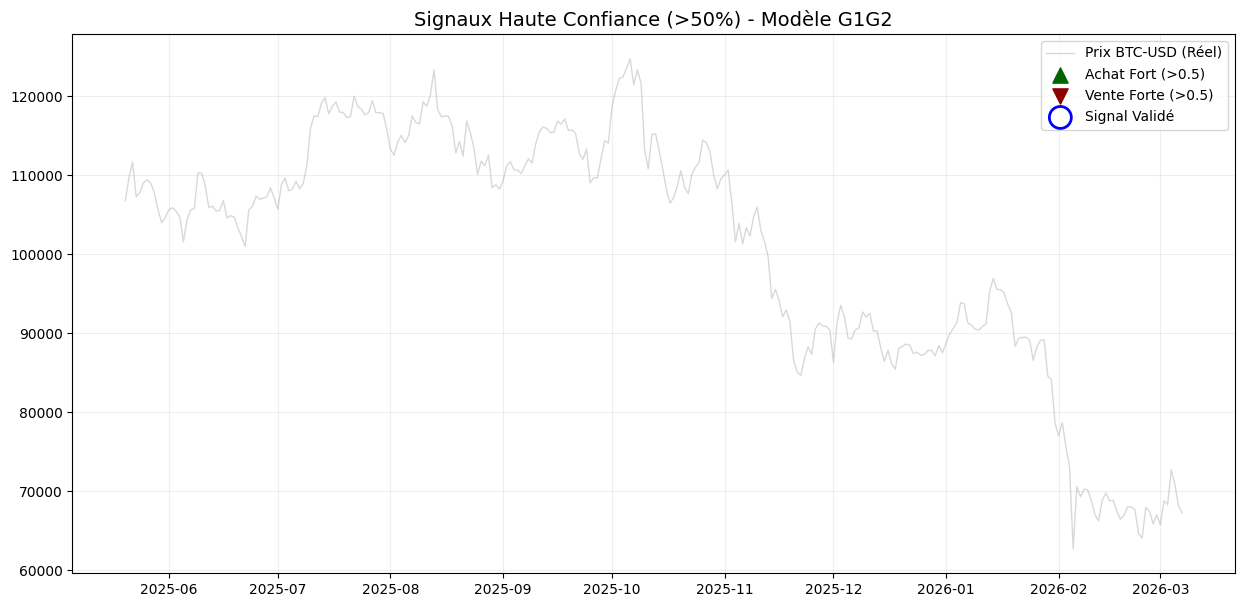

Nombre de signaux totaux : 20
Nombre de signaux forts (>0.5) : 0


In [62]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

# Même chose avec une window plus grande

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    738
2.0    421
0.0    358
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
🚀 Training LSTM...


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


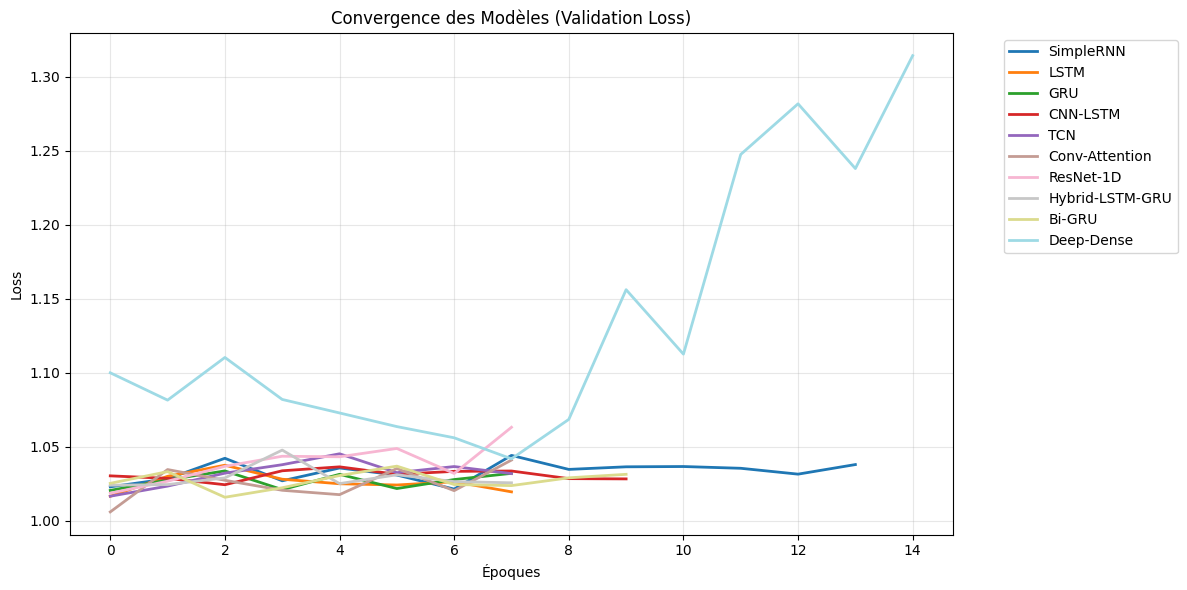


🏆 CLASSEMENT FINAL G1G2
1. TCN             : F1-Score = 0.3814
2. SimpleRNN       : F1-Score = 0.3813
3. LSTM            : F1-Score = 0.3813
4. GRU             : F1-Score = 0.3813
5. CNN-LSTM        : F1-Score = 0.3813
6. Conv-Attention  : F1-Score = 0.3813
7. ResNet-1D       : F1-Score = 0.3813
8. Hybrid-LSTM-GRU : F1-Score = 0.3813
9. Bi-GRU          : F1-Score = 0.3813
10. Deep-Dense      : F1-Score = 0.3708


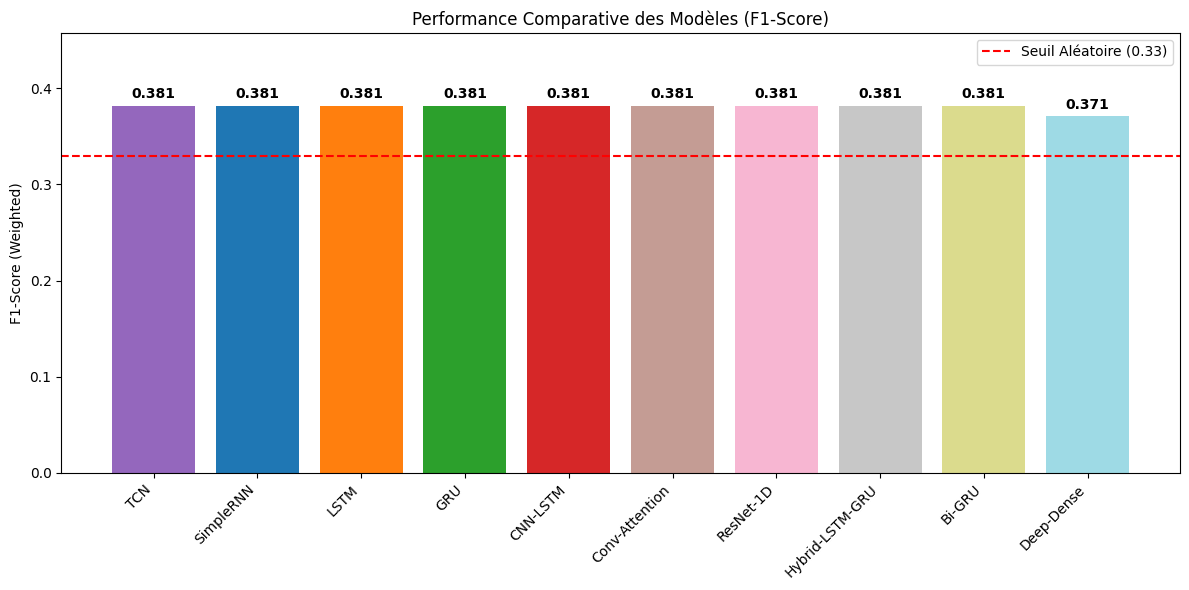

In [ ]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 100
HORIZON = 7
THRESHOLD = 0.035

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


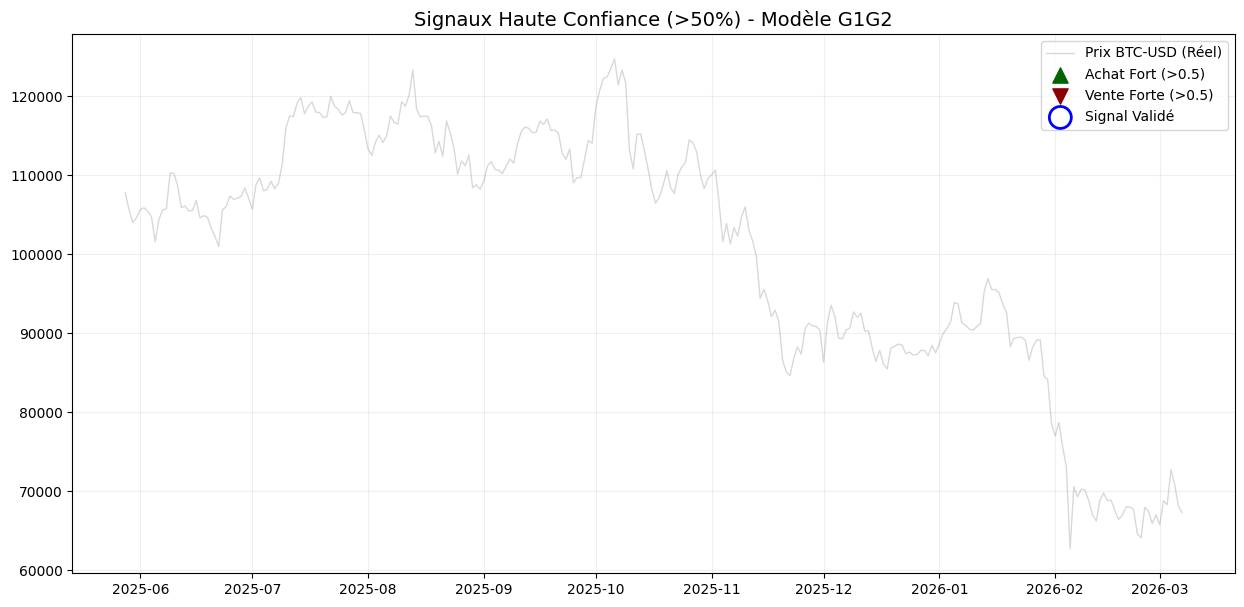

Nombre de signaux totaux : 8
Nombre de signaux forts (>0.5) : 0


In [64]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

# encore moins loin les datas

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    372
2.0    228
0.0    187
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
🚀 Training LSTM...


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


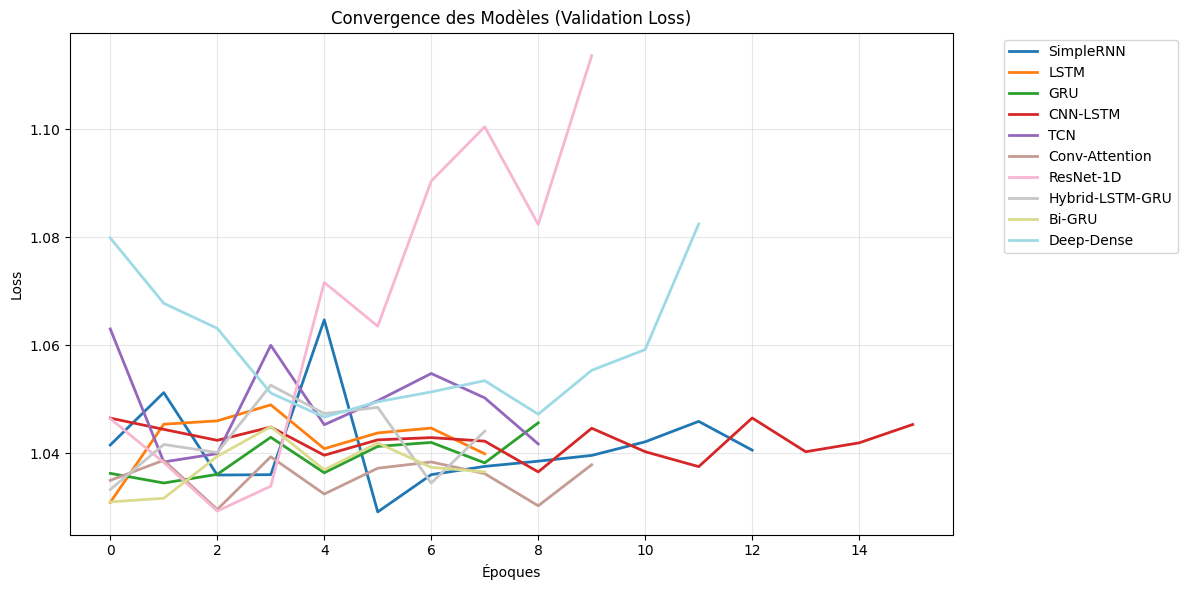


🏆 CLASSEMENT FINAL G1G2
1. Deep-Dense      : F1-Score = 0.4472
2. TCN             : F1-Score = 0.3349
3. LSTM            : F1-Score = 0.3333
4. GRU             : F1-Score = 0.3333
5. CNN-LSTM        : F1-Score = 0.3333
6. Conv-Attention  : F1-Score = 0.3333
7. ResNet-1D       : F1-Score = 0.3333
8. Hybrid-LSTM-GRU : F1-Score = 0.3333
9. Bi-GRU          : F1-Score = 0.3333
10. SimpleRNN       : F1-Score = 0.3272


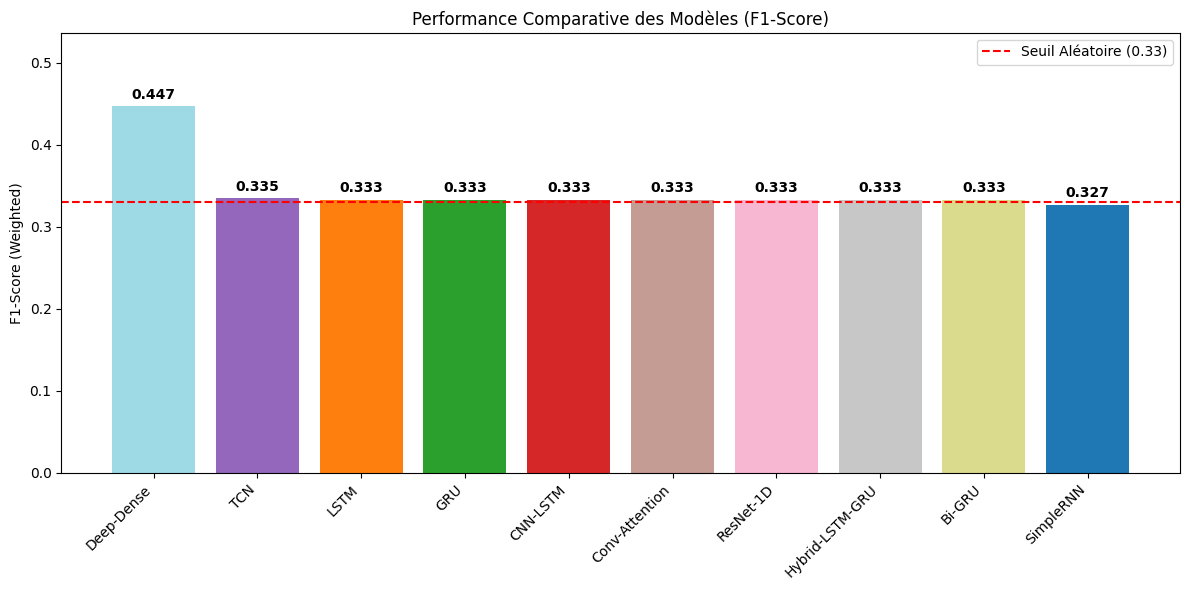

In [ ]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 60
HORIZON = 7
THRESHOLD = 0.035

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2024-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


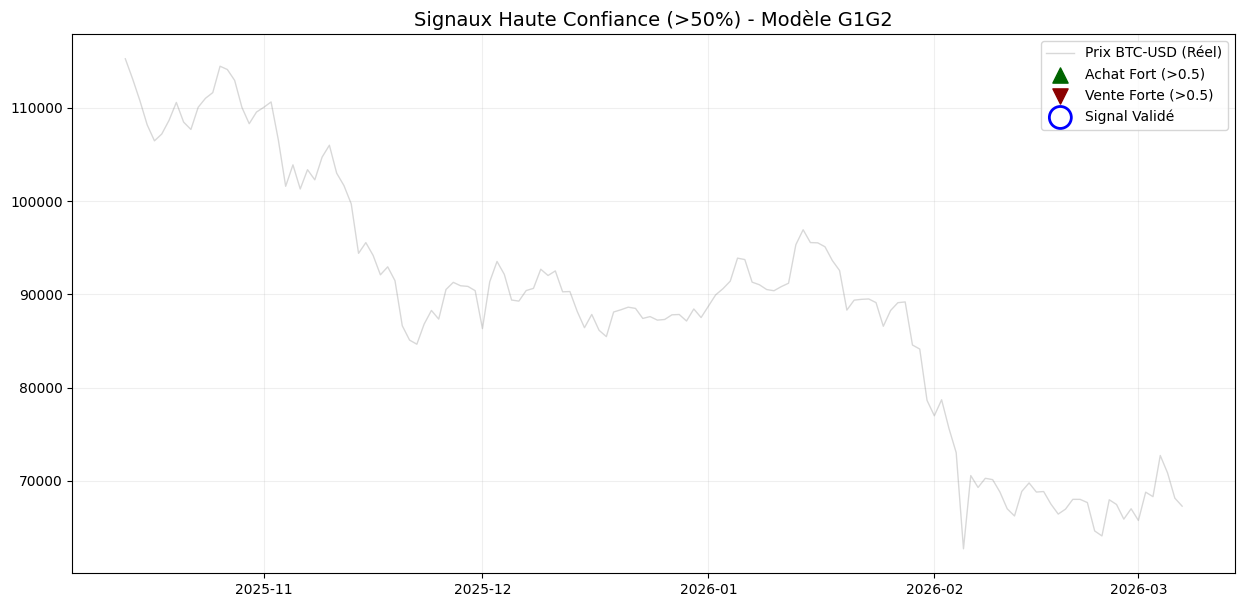

Nombre de signaux totaux : 43
Nombre de signaux forts (>0.5) : 0


In [66]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

## --> Pareil qu'avant mais on change l'horizon de 7 à 1

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    1293
2.0     125
0.0     105
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
🚀 Training LSTM...


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


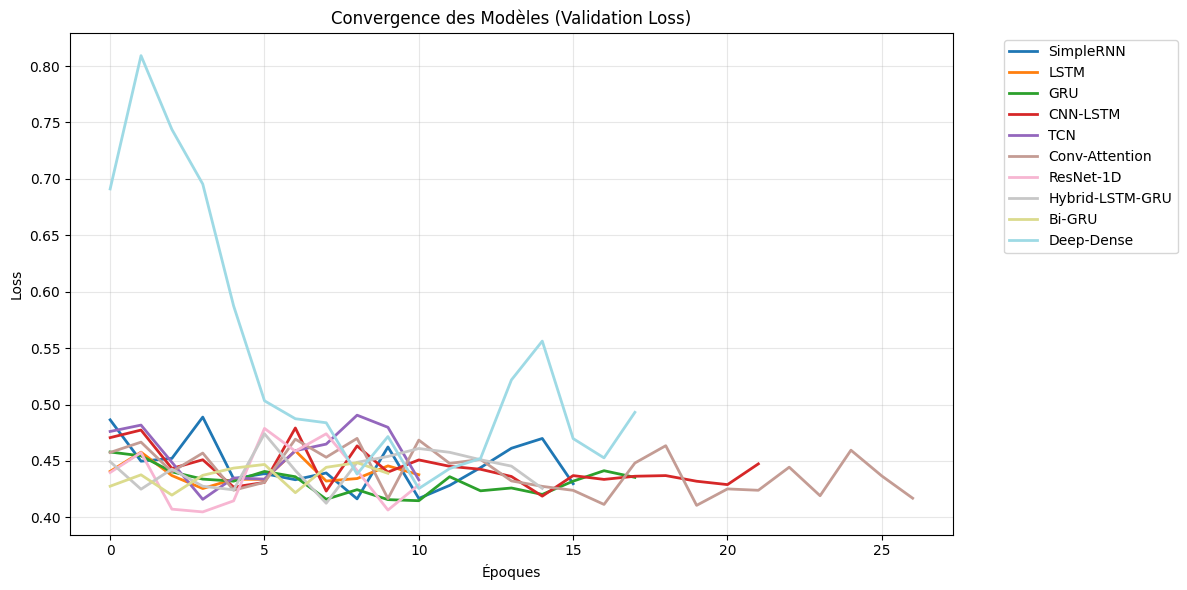


🏆 CLASSEMENT FINAL G1G2
1. SimpleRNN       : F1-Score = 0.8443
2. LSTM            : F1-Score = 0.8443
3. GRU             : F1-Score = 0.8443
4. CNN-LSTM        : F1-Score = 0.8443
5. TCN             : F1-Score = 0.8443
6. Conv-Attention  : F1-Score = 0.8443
7. ResNet-1D       : F1-Score = 0.8443
8. Hybrid-LSTM-GRU : F1-Score = 0.8443
9. Bi-GRU          : F1-Score = 0.8443
10. Deep-Dense      : F1-Score = 0.8443


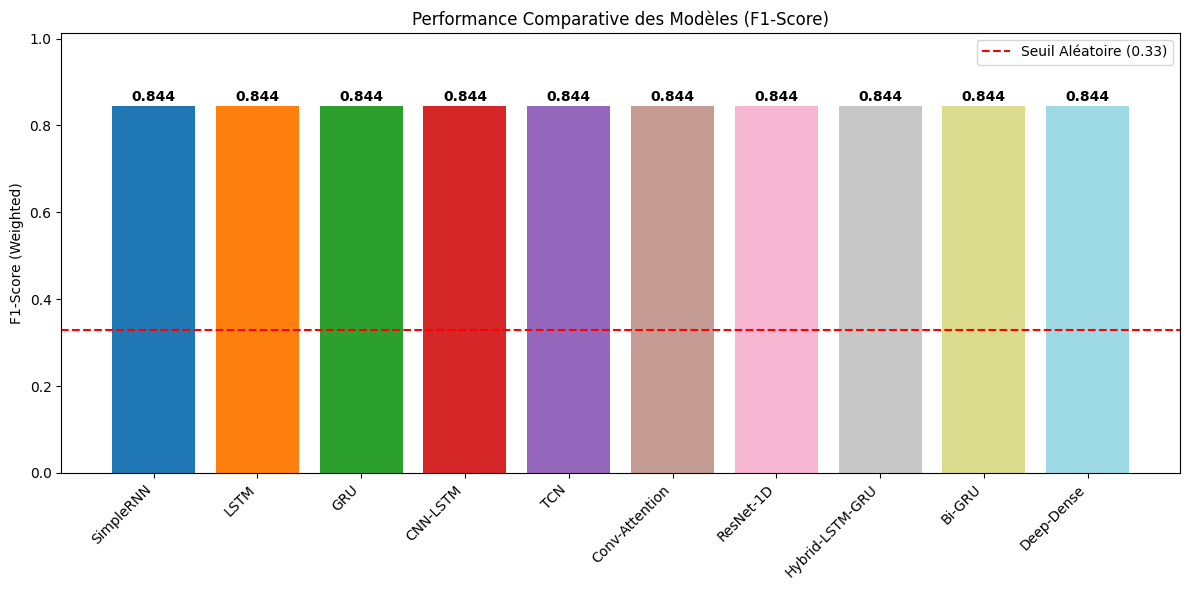

In [67]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 60
HORIZON = 1
THRESHOLD = 0.035  # +3% pour UP, -3% pour DOWN

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


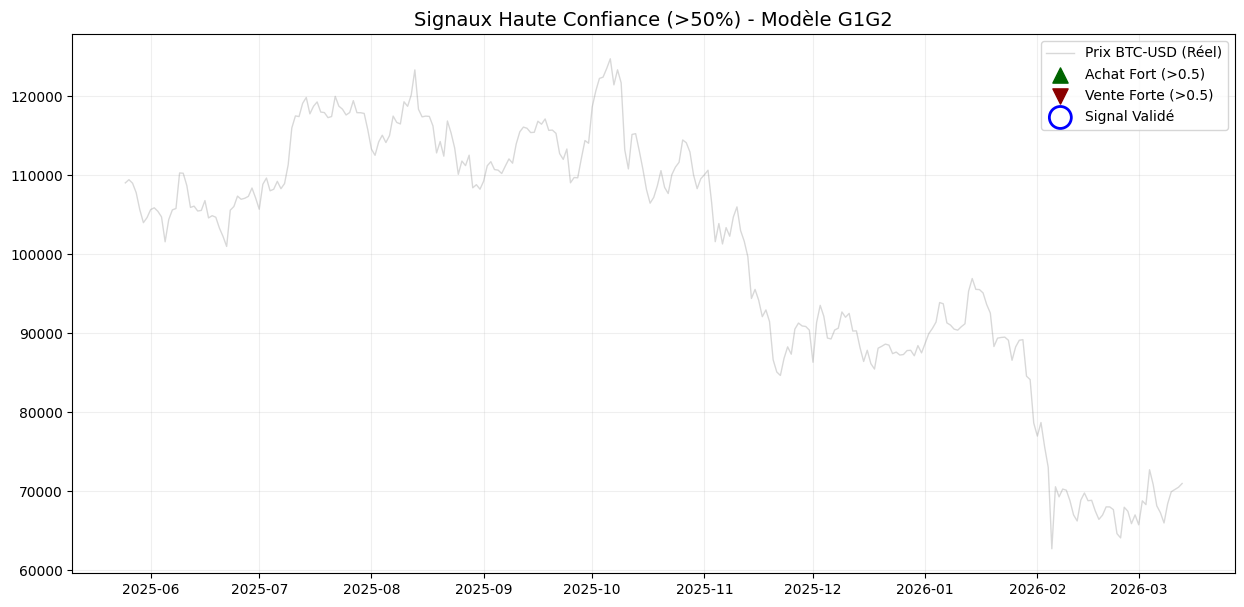

Nombre de signaux totaux : 0
Nombre de signaux forts (>0.5) : 0


In [68]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

## --> Tjrs à 1 jour mais on change la window

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    1293
2.0     125
0.0     105
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
🚀 Training LSTM...


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


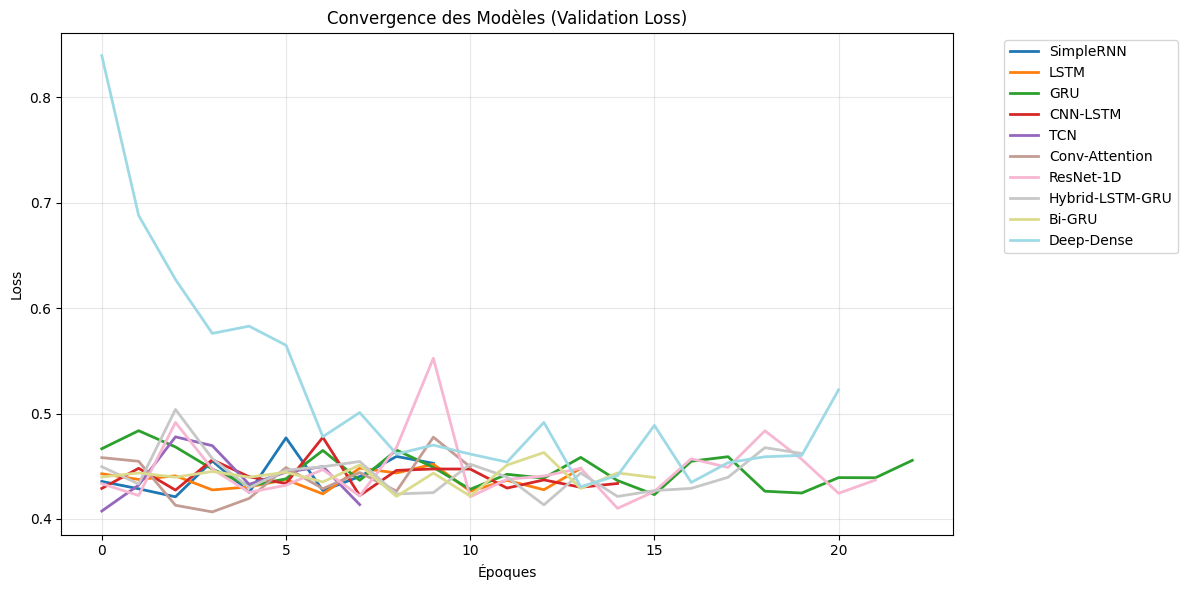


🏆 CLASSEMENT FINAL G1G2
1. SimpleRNN       : F1-Score = 0.8435
2. LSTM            : F1-Score = 0.8435
3. GRU             : F1-Score = 0.8435
4. CNN-LSTM        : F1-Score = 0.8435
5. TCN             : F1-Score = 0.8435
6. Conv-Attention  : F1-Score = 0.8435
7. ResNet-1D       : F1-Score = 0.8435
8. Hybrid-LSTM-GRU : F1-Score = 0.8435
9. Bi-GRU          : F1-Score = 0.8435
10. Deep-Dense      : F1-Score = 0.8435


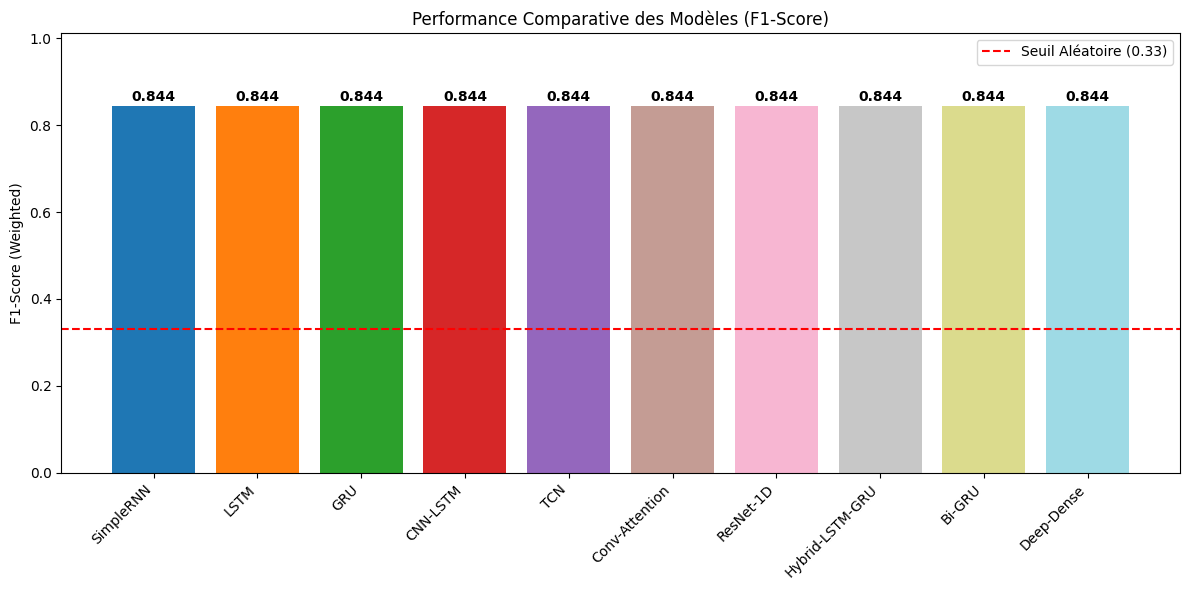

In [69]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 20
HORIZON = 1
THRESHOLD = 0.035  # +3% pour UP, -3% pour DOWN

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

# Au lieu de regarder JUSTE le prix dans 10 jours (trop volatile)
# On regarde la moyenne du prix entre le jour 8, 9 et 10.

future_price_smooth = df['Close'].shift(-HORIZON).rolling(window=3).mean()
future_change = future_price_smooth / df['Close'] - 1

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


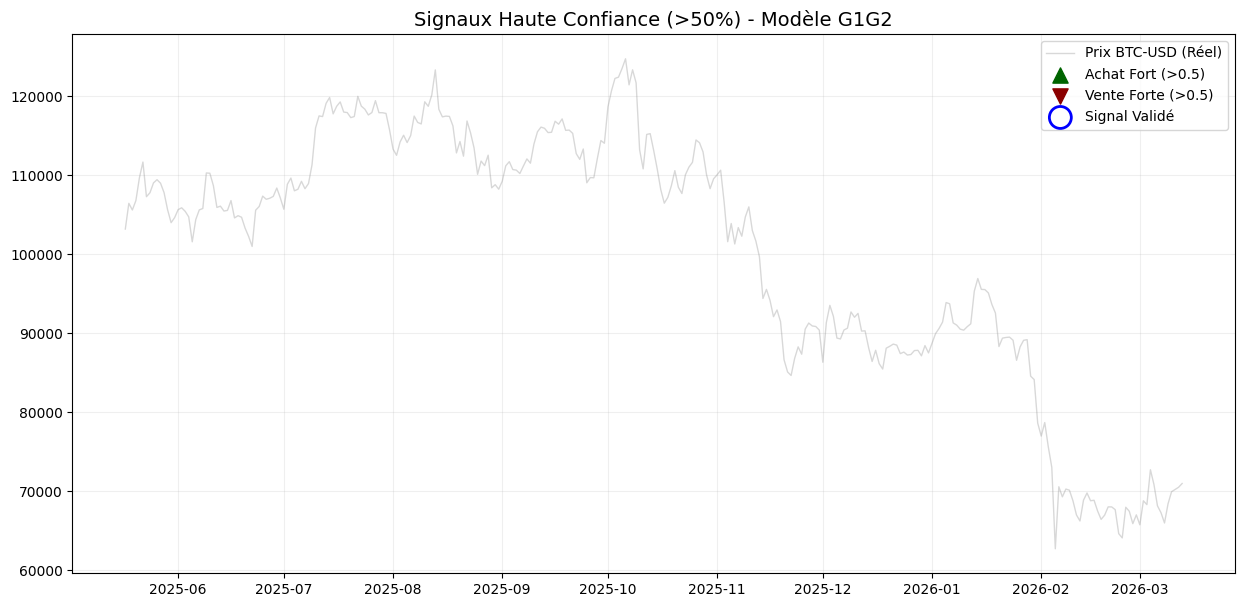

Nombre de signaux totaux : 0
Nombre de signaux forts (>0.5) : 0


In [70]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

# 1 - à horizon 10 jours normal comme avant

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    607
2.0    481
0.0    426
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
🚀 Training LSTM...


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


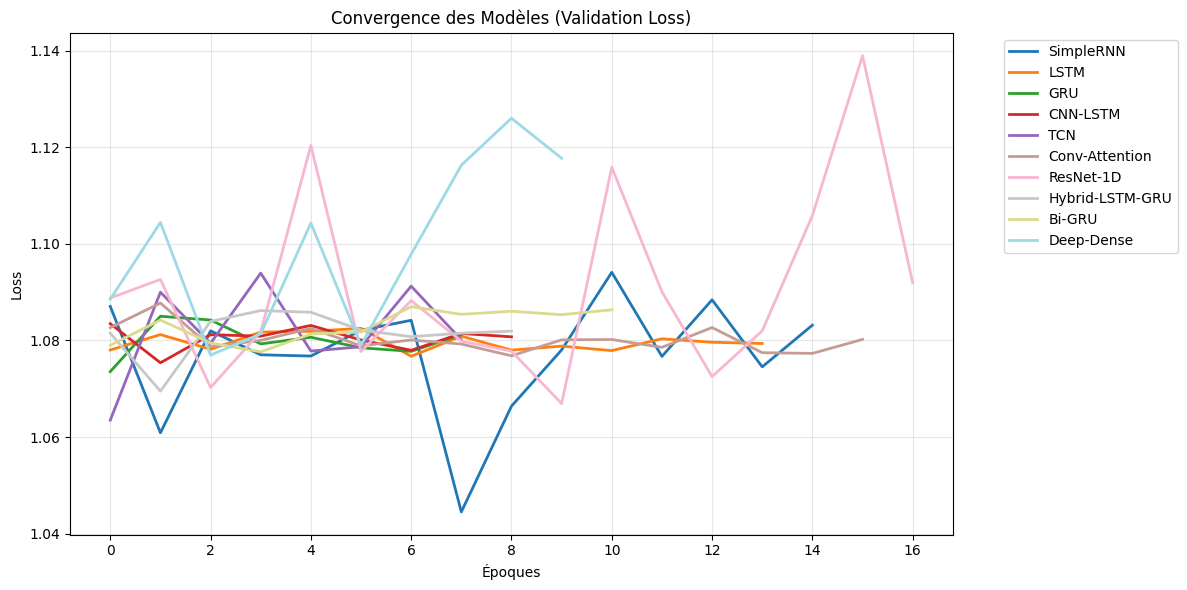


🏆 CLASSEMENT FINAL G1G2
1. SimpleRNN       : F1-Score = 0.3848
2. ResNet-1D       : F1-Score = 0.3730
3. CNN-LSTM        : F1-Score = 0.3009
4. TCN             : F1-Score = 0.3003
5. Bi-GRU          : F1-Score = 0.2906
6. Hybrid-LSTM-GRU : F1-Score = 0.2870
7. Deep-Dense      : F1-Score = 0.2646
8. GRU             : F1-Score = 0.2512
9. LSTM            : F1-Score = 0.2489
10. Conv-Attention  : F1-Score = 0.1588


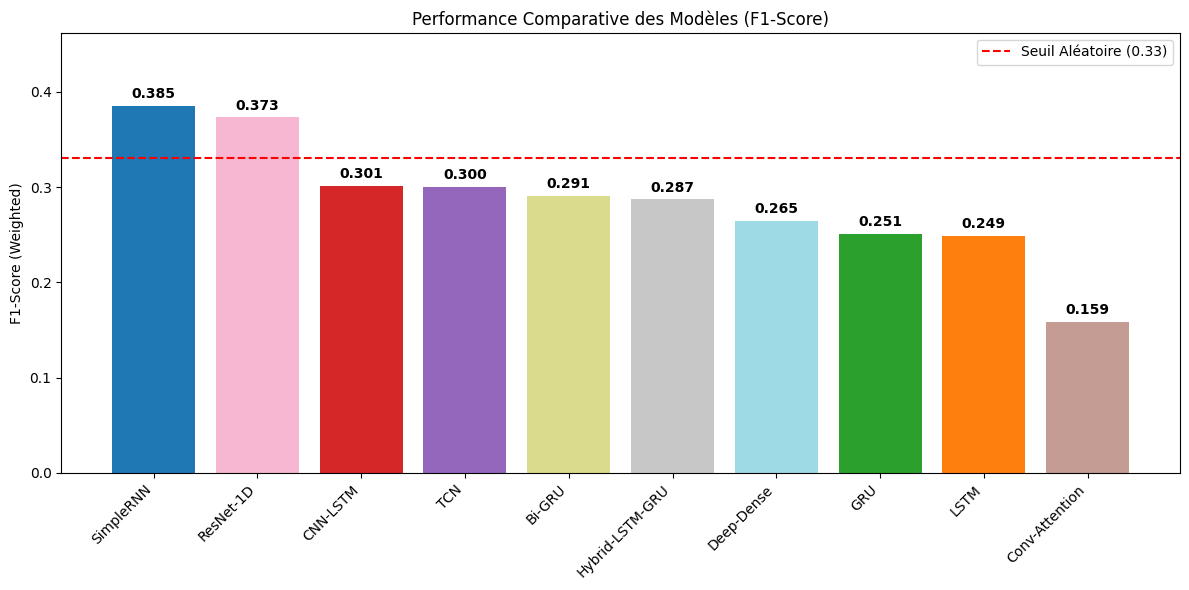

In [71]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 50
HORIZON = 10
THRESHOLD = 0.035  # +3% pour UP, -3% pour DOWN

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


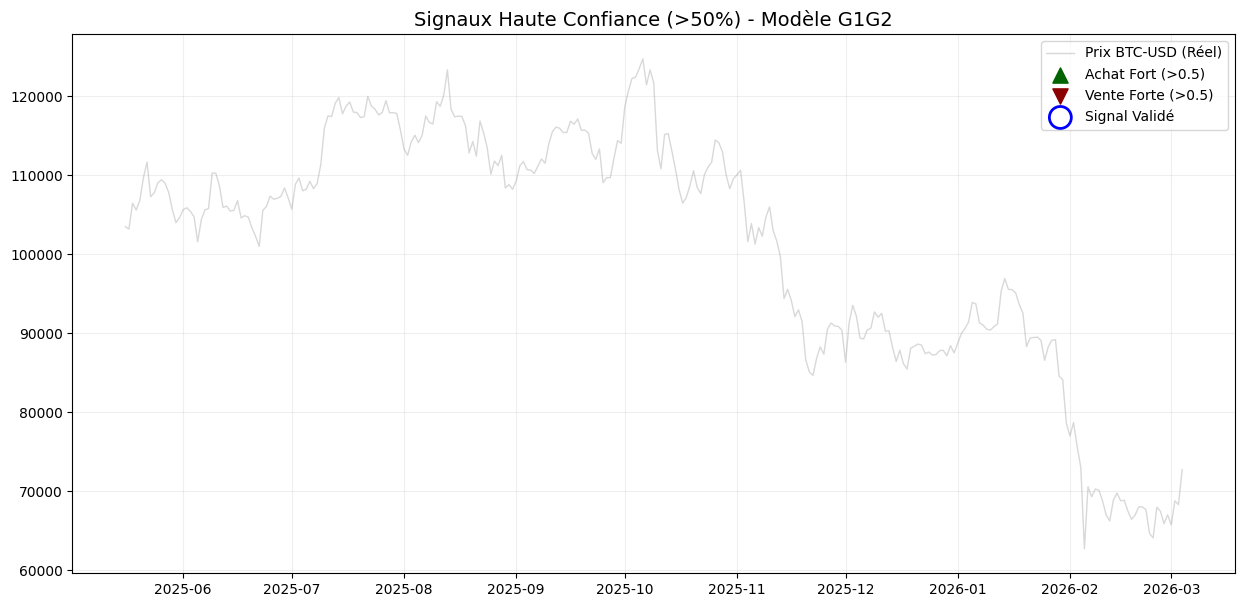

Nombre de signaux totaux : 259
Nombre de signaux forts (>0.5) : 0


In [72]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

# 2- en faisant la modif de lissage

[*********************100%***********************]  1 of 1 completed

Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'target']
Distribution des classes :
target
1.0    645
2.0    467
0.0    400
Name: count, dtype: int64


🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
🚀 Training LSTM...


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


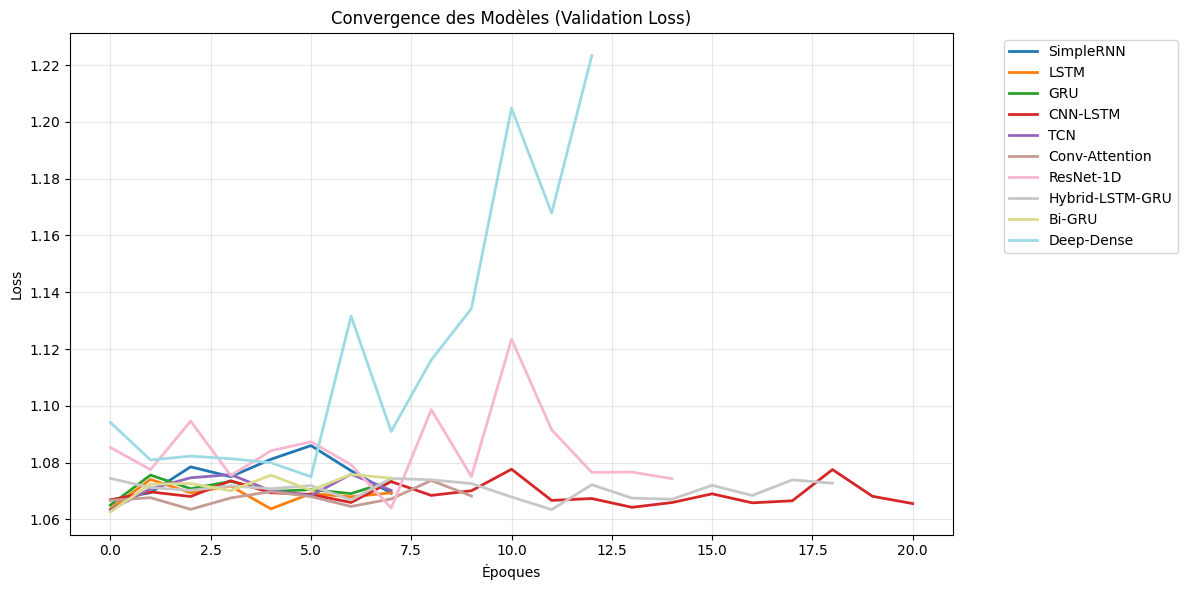


🏆 CLASSEMENT FINAL G1G2
1. ResNet-1D       : F1-Score = 0.3894
2. Deep-Dense      : F1-Score = 0.3859
3. TCN             : F1-Score = 0.3491
4. SimpleRNN       : F1-Score = 0.3443
5. LSTM            : F1-Score = 0.2979
6. GRU             : F1-Score = 0.2979
7. CNN-LSTM        : F1-Score = 0.2979
8. Conv-Attention  : F1-Score = 0.2979
9. Hybrid-LSTM-GRU : F1-Score = 0.2979
10. Bi-GRU          : F1-Score = 0.2979


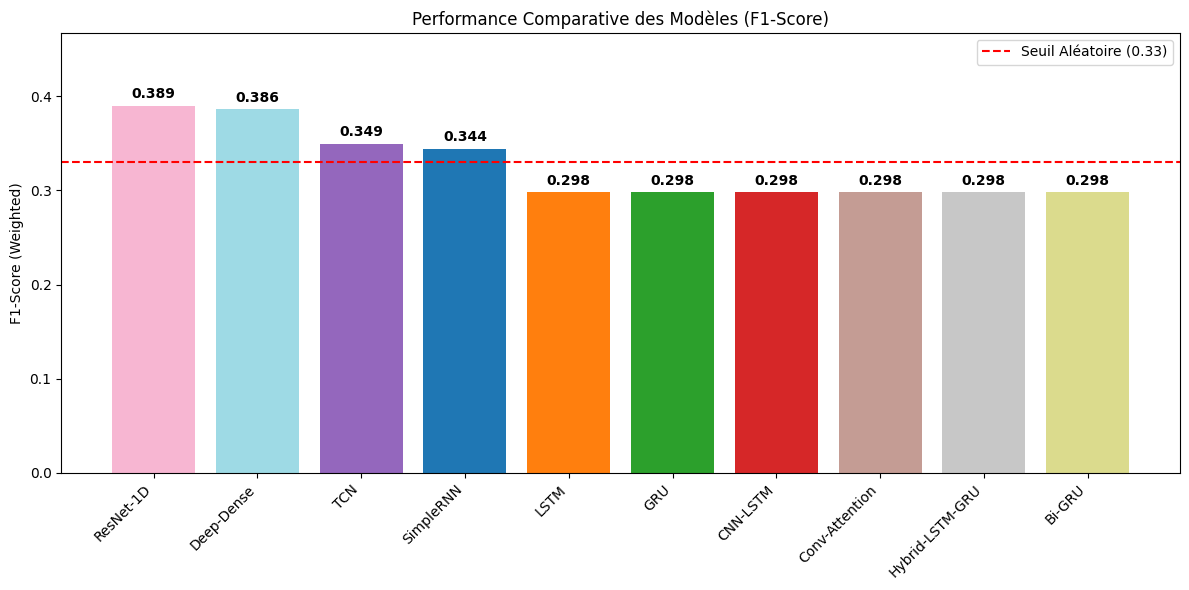

In [73]:
# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"
WINDOW_SIZE = 50
HORIZON = 10
THRESHOLD = 0.035  # +3% pour UP, -3% pour DOWN

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_price_smooth = df['Close'].shift(-HORIZON).rolling(window=3).mean()
future_change = future_price_smooth / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


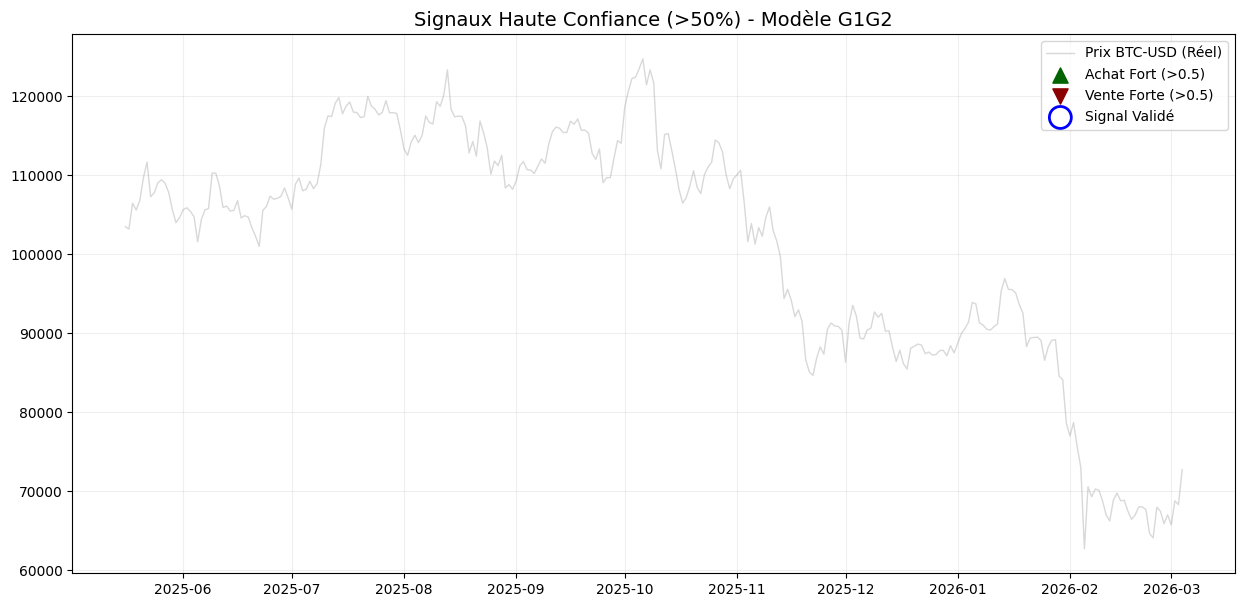

Nombre de signaux totaux : 186
Nombre de signaux forts (>0.5) : 0


In [74]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

---

## On passe à AAPL (pas vrmt de raison mais faut tester)

[*********************100%***********************]  1 of 1 completed


Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Volatility', 'MACD', 'STOCH', 'BB_width', 'ADX', 'target']
Distribution des classes :
target
2.0    1041
1.0     905
0.0     582
Name: count, dtype: int64
🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
🚀 Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


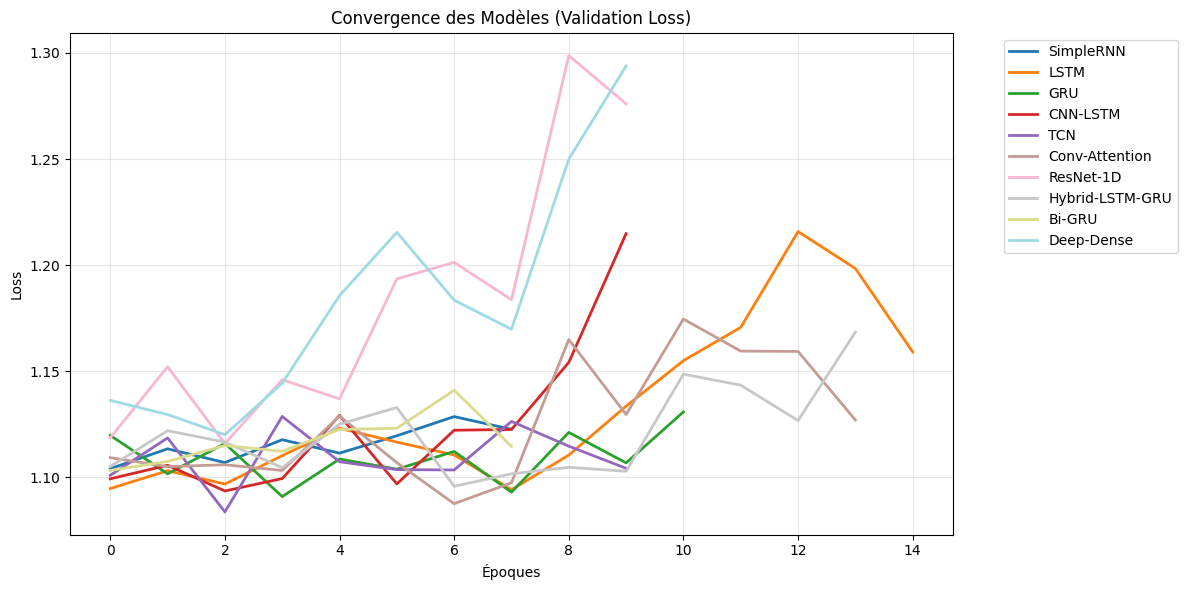


🏆 CLASSEMENT FINAL G1G2
1. LSTM            : F1-Score = 0.3662
2. TCN             : F1-Score = 0.3522
3. CNN-LSTM        : F1-Score = 0.3479
4. Hybrid-LSTM-GRU : F1-Score = 0.3446
5. GRU             : F1-Score = 0.3329
6. ResNet-1D       : F1-Score = 0.3299
7. Deep-Dense      : F1-Score = 0.3170
8. SimpleRNN       : F1-Score = 0.3149
9. Conv-Attention  : F1-Score = 0.3140
10. Bi-GRU          : F1-Score = 0.2268


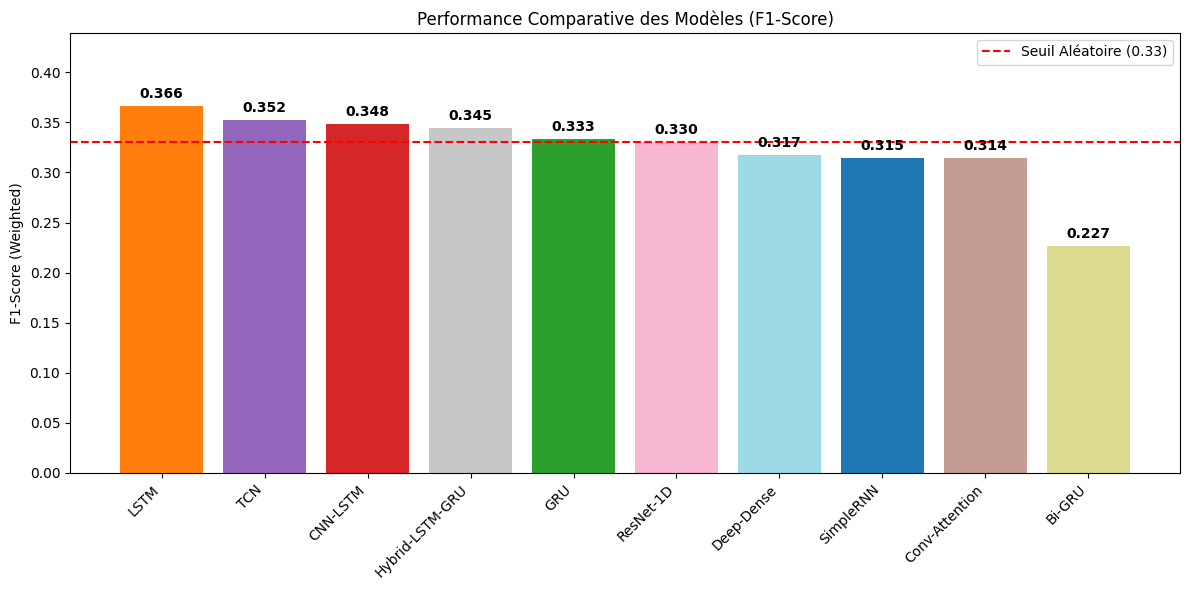

In [75]:
# --- 1. CONFIGURATION ---
TICKER = "AAPL"
WINDOW_SIZE = 40
HORIZON = 10
THRESHOLD = 0.025  # +3% pour UP, -3% pour DOWN

# --- 2. PRÉPARATION DES DONNÉES ---
# On force auto_adjust=True pour éviter les soucis de colonnes, 
# yfinance transformera 'Adj Close' en 'Close' automatiquement.
df = yf.download(TICKER, start="2016-01-01", auto_adjust=True)

# Sécurité MultiIndex : si yfinance renvoie les colonnes avec le ticker (ex: ('Close', 'BTC-USD'))
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# On utilise désormais 'Close' car auto_adjust a fusionné Adj Close dedans
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

macd = ta.macd(df['Close'])
df['MACD'] = macd.iloc[:, 0] / df['Close'] # Utilise la première colonne du MACD

stoch = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH'] = stoch.iloc[:, 0] / 100 # Utilise la ligne %K

bbands = ta.bbands(df['Close'], length=20, std=2)
# On calcule la largeur (Upper - Lower) en utilisant les positions plutôt que les noms
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']

adx = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX'] = adx.iloc[:, 0] / 100

# On drop les NaN créés par les indicateurs
df.dropna(inplace=True)

# Labeling Triple Barrier (On utilise 'Close')
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x > THRESHOLD: return 2   # BUY (UP)
    if x < -THRESHOLD: return 0  # SELL (DOWN)
    return 1                     # HOLD (NEUTRAL)

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
features = ['returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 'BB_width']
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics

# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


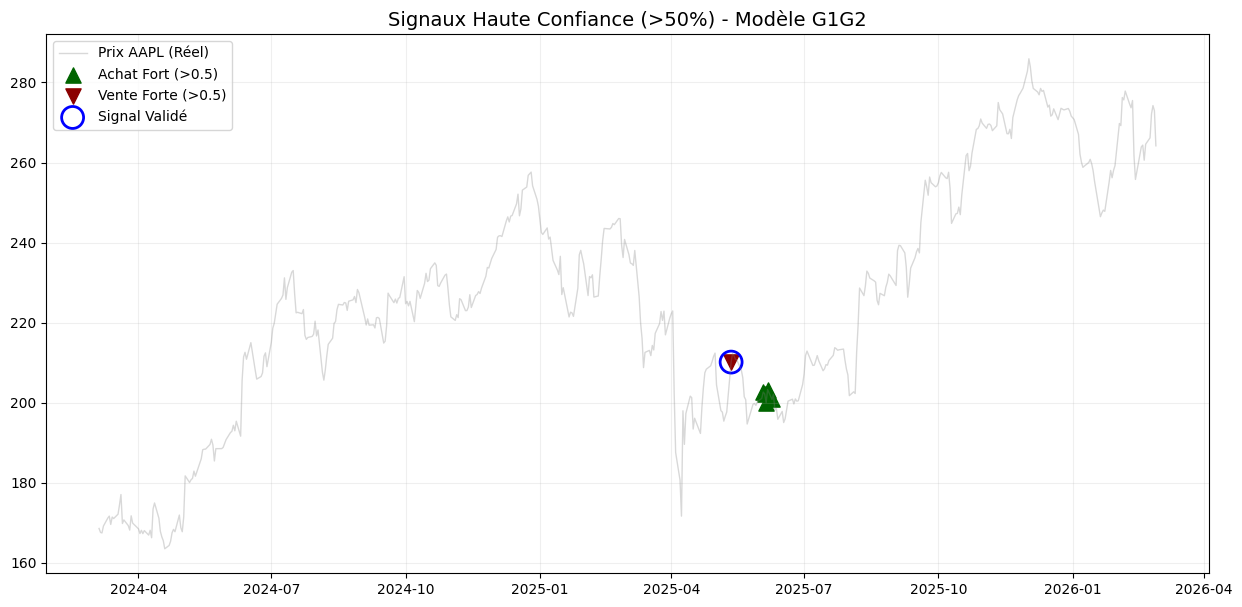

Nombre de signaux totaux : 258
Nombre de signaux forts (>0.5) : 6


In [76]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")

[*********************100%***********************]  1 of 1 completed


Structure des colonnes : ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'RSI', 'Vol_Rel', 'MACD_Hist', 'STOCH', 'BB_dist', 'ADX', 'target']
Distribution des classes :
target
2    1017
1     914
0     582
Name: count, dtype: int64
🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
🚀 Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


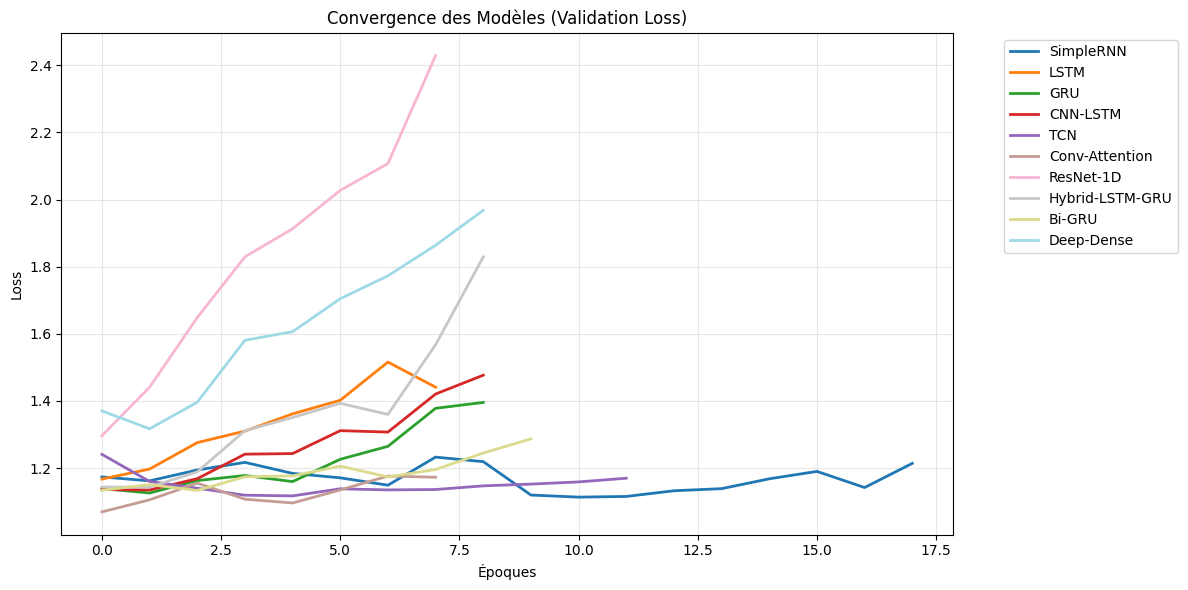


🏆 CLASSEMENT FINAL G1G2
1. TCN             : F1-Score = 0.3762
2. Conv-Attention  : F1-Score = 0.3622
3. Bi-GRU          : F1-Score = 0.3595
4. GRU             : F1-Score = 0.3504
5. Hybrid-LSTM-GRU : F1-Score = 0.3418
6. ResNet-1D       : F1-Score = 0.3386
7. SimpleRNN       : F1-Score = 0.3361
8. Deep-Dense      : F1-Score = 0.3173
9. CNN-LSTM        : F1-Score = 0.2864
10. LSTM            : F1-Score = 0.2363


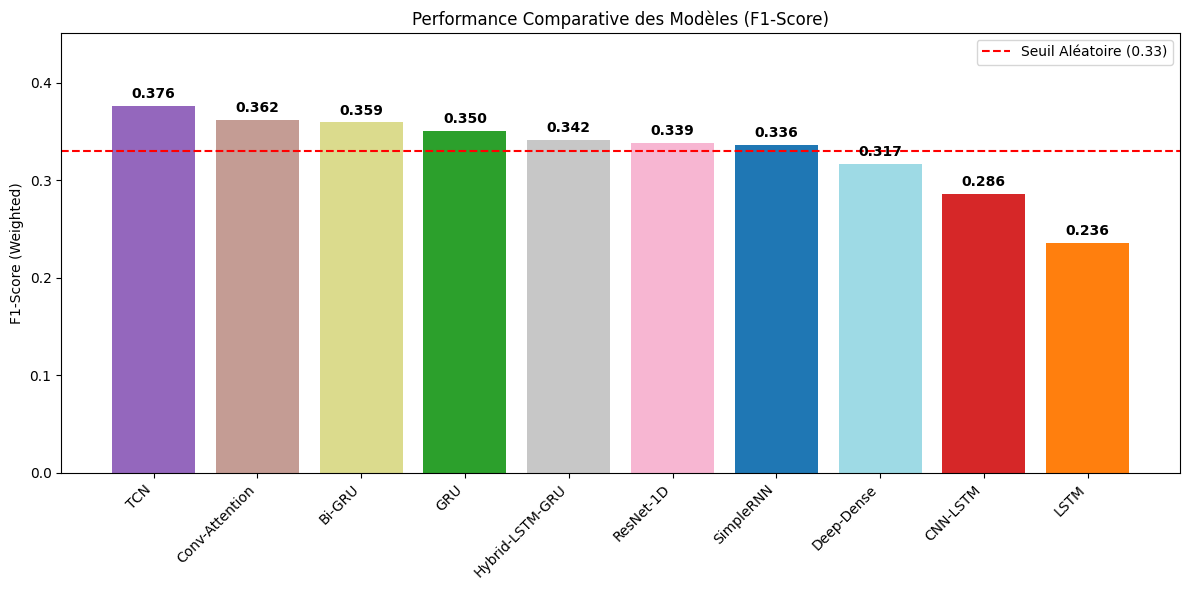

In [77]:
# --- 1. CONFIGURATION ---
TICKER = "AAPL"
WINDOW_SIZE = 80
HORIZON = 10
THRESHOLD = 0.025

# --- 2. PRÉPARATION & SCALING ---
df = yf.download(TICKER, start="2016-01-01", auto_adjust=True)
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

# Indicateurs techniques stationnarisés
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Vol_Rel'] = df['returns'].rolling(10).std() / df['returns'].rolling(50).std() # Volatilité relative
df['MACD_Hist'] = ta.macd(df['Close']).iloc[:, 2] / df['Close'] # Histogramme normalisé
df['STOCH'] = ta.stoch(df['High'], df['Low'], df['Close']).iloc[:, 0] / 100
bb = ta.bbands(df['Close'], length=20)
df['BB_dist'] = (df['Close'] - bb.iloc[:, 0]) / (bb.iloc[:, 2] - bb.iloc[:, 0]) # Position relative dans les bandes
df['ADX'] = ta.adx(df['High'], df['Low'], df['Close']).iloc[:, 0] / 100

df.dropna(inplace=True)

# Labeling
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1
df['target'] = future_change.apply(lambda x: 2 if x > THRESHOLD else (0 if x < -THRESHOLD else 1))
df.dropna(inplace=True)

# --- BOOSTER 1 : ROBUST SCALING ---
features = ['returns', 'RSI', 'Vol_Rel', 'ADX', 'MACD_Hist', 'STOCH', 'BB_dist']
scaler = RobustScaler()
df[features] = scaler.fit_transform(df[features])

print(f"Structure des colonnes : {df.columns.tolist()}")
print(f"Distribution des classes :\n{df['target'].value_counts()}")

# Séquençage
X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=3)

# Split Temporel (Respect de la chronologie G1G2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels = y[split:] # Pour les metrics


# --- BOOSTER 2 : CALCUL DES POIDS DE CLASSES ---
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(cw))


# --- 3. ARCHITECTURES VARIÉES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        GRU(32),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    # Le TCN est souvent très performant sur les séries temporelles financières
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Simple Attention Mechanism
    query = Dense(64)(x)
    value = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x = GlobalAveragePooling1D()(attn_out)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet_1d():
    inputs = Input(shape=(WINDOW_SIZE, len(features)))
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    # Residual Block
    res = Conv1D(64, 3, padding='same', activation='relu')(x)
    res = Conv1D(64, 3, padding='same')(res)
    x = Add()([x, res])
    x = Flatten()(x)
    outputs = Dense(3, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT GLOBAL ---

model_factories = {
    "SimpleRNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Conv-Attention": build_conv_attention,
    "ResNet-1D": build_resnet_1d,
    "Hybrid-LSTM-GRU": build_hybrid_lstm_gru,
    "Bi-GRU": build_bigru,
    "Deep-Dense": build_deep_dense
}

# --- 1. PRÉPARATION DES COULEURS ---
model_names = list(model_factories.keys())
color_palette = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map = dict(zip(model_names, color_palette))

# --- 2. ENTRAÎNEMENT & COLLECTE ---
histories = {}
f1_results = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    
    # EarlyStopping pour la propreté
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    h = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_test, y_test), 
        class_weight=class_weights, 
        callbacks=[es],
        verbose=0
    )
    
    # Prédiction et Score
    y_pred = np.argmax(model.predict(X_test), axis=1)
    score = f1_score(y_test_labels, y_pred, average='weighted')
    f1_results[name] = score
    
    # Courbe de Loss avec couleur fixe
    plt.plot(h.history['val_loss'], label=f'{name}', color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. CLASSEMENT FINAL & BAR CHART ---

# Tri des résultats par score décroissant
sorted_results = dict(sorted(f1_results.items(), key=lambda item: item[1], reverse=True))

print("\n" + "="*30)
print("🏆 CLASSEMENT FINAL G1G2")
print("="*30)
for i, (name, score) in enumerate(sorted_results.items()):
    print(f"{i+1}. {name:15} : F1-Score = {score:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), 
               color=[color_map[name] for name in sorted_results.keys()])

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(y=0.33, color='red', linestyle='--', label="Seuil Aléatoire (0.33)")
plt.title("Performance Comparative des Modèles (F1-Score)")
plt.ylabel("F1-Score (Weighted)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(f1_results.values()) * 1.2) # Marge pour les labels
plt.legend()
plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


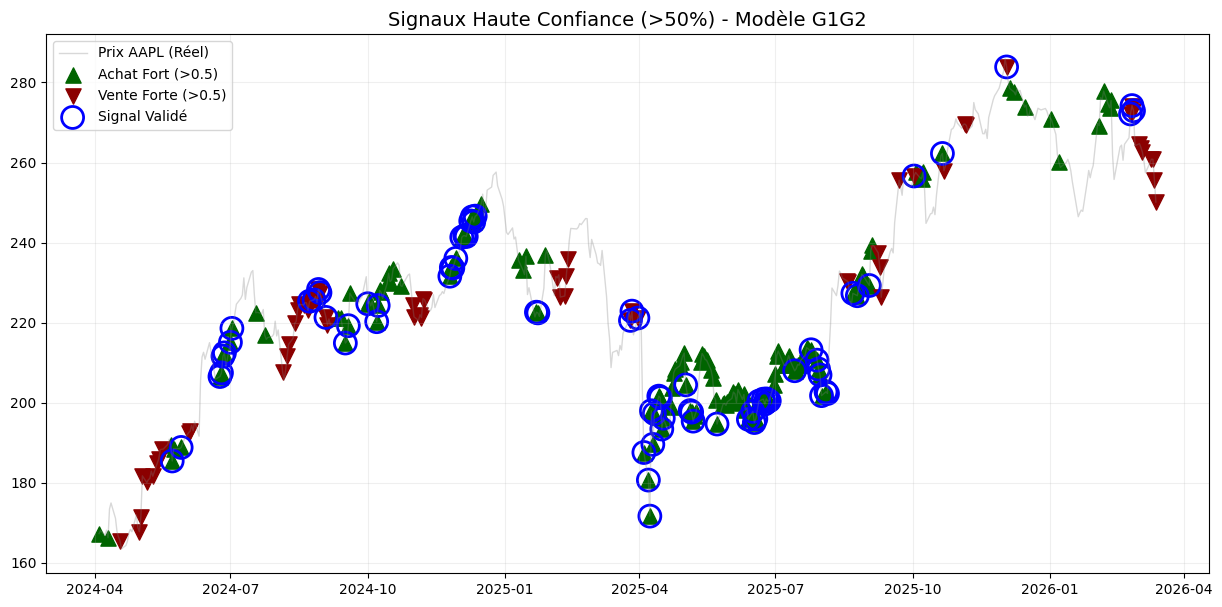

Nombre de signaux totaux : 378
Nombre de signaux forts (>0.5) : 215


In [78]:
# --- CONFIGURATION DU FILTRE ---
CONFIDENCE_THRESHOLD = 0.5  # On ne garde que les signaux "forts"

# --- 1. Préparer les données ---
test_dates = df.index[-len(y_test_labels):]
test_prices = df['Close'].iloc[-len(y_test_labels):].values

# --- 2. Obtenir les probabilités ---
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_pred_max_prob = np.max(y_pred_probs, axis=1) # On récupère la proba du choix

# --- 3. Appliquer le filtre de confiance ---
# On ne garde que si la proba > 0.5 ET que ce n'est pas "Neutral"
strong_signal_mask = (y_pred_max_prob > CONFIDENCE_THRESHOLD) & (y_pred_classes != 1)

# --- 4. Tracer le graphique ---
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label=f'Prix {TICKER} (Réel)', color='gray', alpha=0.3, linewidth=1)

# Indices des signaux filtrés
up_indices = np.where(strong_signal_mask & (y_pred_classes == 2))[0]
down_indices = np.where(strong_signal_mask & (y_pred_classes == 0))[0]

# Affichage des signaux robustes
plt.scatter(test_dates[up_indices], test_prices[up_indices], 
            label=f'Achat Fort (>{CONFIDENCE_THRESHOLD})', color='darkgreen', marker='^', s=120)
plt.scatter(test_dates[down_indices], test_prices[down_indices], 
            label=f'Vente Forte (>{CONFIDENCE_THRESHOLD})', color='darkred', marker='v', s=120)

# Surlignage des succès parmi les signaux forts
correct_indices = np.where((y_pred_classes == y_test_labels) & strong_signal_mask)[0]
plt.scatter(test_dates[correct_indices], test_prices[correct_indices], 
            facecolors='none', edgecolors='blue', s=250, label='Signal Validé', linewidth=2)

plt.title(f"Signaux Haute Confiance (>50%) - Modèle G1G2", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

# Petit calcul de stats pour ton rapport
print(f"Nombre de signaux totaux : {np.sum(y_pred_classes != 1)}")
print(f"Nombre de signaux forts (>0.5) : {np.sum(strong_signal_mask)}")